<a href="https://colab.research.google.com/github/amit-devs/ecommerce-recommendation-system-2/blob/main/_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/@new/final_dataset_v3.csv"
df = pd.read_csv(path)

print(df.head())
print("Shape:", df.shape)

Mounted at /content/drive
         asin                                              title  price_value  \
0  B00021NY28  Gloria Vanderbilt Women's Amanda Classic High ...      16.7665   
1  B0006U6C0Q           Wrangler Men's Cowboy Cut Slim Fit Jeans      29.9843   
2  B0007CKJSY  Wrangler Men's 13MWZ Cowboy Cut Original Fit J...      18.9464   
3  B0008EOG9E            Lee Men's Regular Fit Straight Leg Jean      34.9050   
4  B0008EOGAS            Lee Men's Regular Fit Straight Leg Jean      31.9800   

   rating  helpfulVoteCount  sentiment_score  liked  
0     4.4                67         0.269062      1  
1     4.5               294         0.306233      1  
2     4.9               128         0.169829      1  
3     4.8                 2         0.270511      1  
4     4.6                 5         0.264620      1  
Shape: (700, 7)


In [ ]:
X = df[['price_value', 'helpfulVoteCount', 'sentiment_score']]
y = df['liked']

In [ ]:
#STEP 4: Train-Test Split (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

In [ ]:
#STEP 5: Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#STEP 6: Evaluation (70-30)
y_pred = model.predict(X_test)

print("\n===== 70-30 Split =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


===== 70-30 Split =====
Accuracy: 0.985781990521327
Confusion Matrix:
 [[  2   2]
 [  1 206]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.99      1.00      0.99       207

    accuracy                           0.99       211
   macro avg       0.83      0.75      0.78       211
weighted avg       0.98      0.99      0.98       211



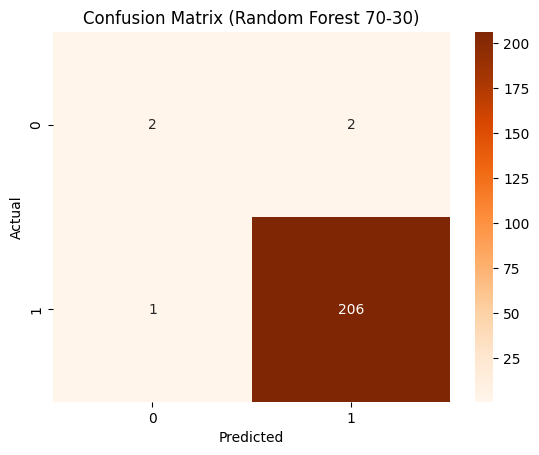

In [ ]:
#STEP 7: Confusion Matrix Graph
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (Random Forest 70-30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#STEP 8: Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42
)

In [ ]:
#STEP 9: Train Again
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#STEP 10: Evaluation (80-20)
y_pred = model.predict(X_test)

print("\n===== 80-20 Split =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


===== 80-20 Split =====
Accuracy: 0.9785714285714285
Confusion Matrix:
 [[  1   1]
 [  2 136]]
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.99      0.99      0.99       138

    accuracy                           0.98       140
   macro avg       0.66      0.74      0.69       140
weighted avg       0.98      0.98      0.98       140



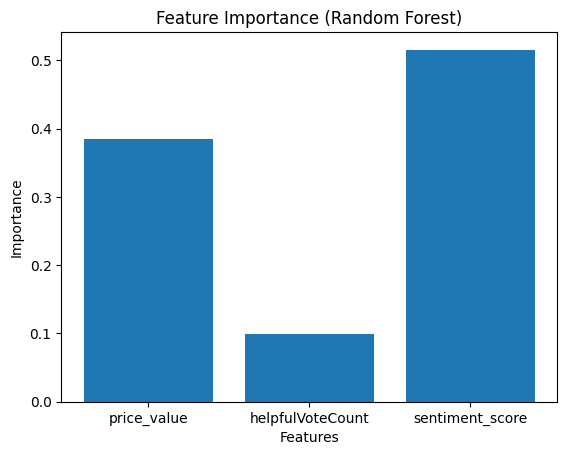

In [ ]:
#STEP 11: Feature Importance Graph
importance = model.feature_importances_
features = ['price_value', 'helpfulVoteCount', 'sentiment_score']

plt.figure()
plt.bar(features, importance)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
#STEP 12: Recommendation System
print("\n===== Recommendation System =====")

search = input("Enter product to search: ")

df_filtered = df[df['title'].str.contains(search, case=False)]

if df_filtered.shape[0] == 0:
    print("No products found!")
else:
    df_filtered = df_filtered.sort_values(
        by=['rating', 'helpfulVoteCount'],
        ascending=False
    )

    top_5 = df_filtered.head(5)

    print("\nTop 5 Recommended Products:\n")

    for i, row in top_5.iterrows():
        print("Title:", row['title'])
        print("Rating:", row['rating'])
        print("Helpful Votes:", row['helpfulVoteCount'])
        print("----------------------------")


===== Recommendation System =====
Enter product to search: shirt

Top 5 Recommended Products:

Title: Dokotoo Women's Short Puff Sleeve Knit Tops 2025 Trendy Crewneck Striped T Shirts Casual Summer Blouses
Rating: 5.0
Helpful Votes: 11
----------------------------
Title: Polo Shirts for Men - Dry Fit Moisture Wicking Black Short Sleeve Performance Golf T Shirts for Casual Work Athletic
Rating: 5.0
Helpful Votes: 2
----------------------------
Title: U.S. Polo Assn. Men's Crew Neck Pocket T-Shirt (Color Group 2 of 2)
Rating: 5.0
Helpful Votes: 0
----------------------------
Title: Hanes Men's EcoSmart Fleece Hoodie Sweatshirt
Rating: 5.0
Helpful Votes: 0
----------------------------
Title: Nautica Men's Short Sleeve Solid Stretch Cotton Pique Polo Shirt
Rating: 5.0
Helpful Votes: 0
----------------------------
